# Algorithm Intercomparison: TDA vs Murray-Simmonds (1991)

Following the evaluation framework of **Bourdin et al. (2022)** — same NCEP SLP dataset, same 1948-2023 period.

Metrics:
- **Hit Rate (HR)** = a / (a+b)   [a=hit, b=miss]
- **False Alarm Rate (FAR)** = c / (a+c)   [c=false alarm]
- **Critical Success Index (CSI)** = a / (a+b+c)

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import sys
import importlib

In [2]:
notebook_path = os.getcwd()
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [3]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import feature_tracking, comparison_tracker

importlib.reload(feature_tracking)
importlib.reload(comparison_tracker)

<module 'comparison_tracker' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/comparison_tracker.py'>

# 10 hpa

## 1. Run M&S tracker (or load from cache)

Simplified Murray-Simmonds (1991):
- Local SLP minima in 3x3 neighbourhood
- Depth >= 1000 Pa (10 hPa)
- Track linking: greedy nearest-neighbour, max 1000 km/day
- Minimum track length: 2 days
- Domain: 0-90 N (same hemisphere as TDA)

In [4]:
ms_tracks = comparison_tracker.run_ms_tracker_cached(
    notebook_directory,
    start_year=1948, end_year=2023,
    depth_threshold_pa=1000.0,
    max_dist_km=1000.0,
    min_track_days=2,
    lat_min=0.0, lat_max=90.0,
)
print(f'Total M&S tracks: {len(ms_tracks)}')

Loaded 9938 M&S tracks from cache: ms_tracks_1948-2023_depth1000_dist1000_mindays2_lat0-90.pkl
Total M&S tracks: 9938


## 2. Load TDA tracks (superlevel = cyclones)

In [5]:
results_sup = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948, end_year=2023,
    data_type='sup',
    notebook_dir=notebook_directory,
    persistence_threshold=1000,
    alpha=0, beta=1,
    distance_threshold=1000,
    matrix_size=172,
)

tda_tracks = comparison_tracker.extract_tda_tracks(results_sup)
print(f'Total TDA tracks: {len(tda_tracks)}')

LOADING CACHED RESULTS
Loading cached results from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sup_1948-2023_pers1000_a0_b1_dist1000_size172.pkl
Cache created: 2026-04-03T09:29:49.631280
Total trajectories: 94169
Cached results loaded successfully!
Total TDA tracks: 94169


## 3. Summary DataFrames

In [6]:
ms_summary  = comparison_tracker.tracks_to_summary(ms_tracks,  label='M&S (1991)')
tda_summary = comparison_tracker.tracks_to_summary(tda_tracks, label='TDA (ours)')

print('M&S summary:')
print(ms_summary[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))
print('\nTDA summary:')
print(tda_summary[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))

M&S summary:
       lifetime_days  genesis_lat  total_displacement_km
count         9938.0       9938.0                 9938.0
mean             2.4         66.5                  345.3
std              1.0         21.2                  471.7
min              2.0         15.0                    0.0
25%              2.0         50.0                    0.0
50%              2.0         62.5                  160.0
75%              3.0         90.0                  583.4
max             34.0         90.0                 5112.9

TDA summary:
       lifetime_days  genesis_lat  total_displacement_km
count        94169.0      94169.0                94169.0
mean             1.2         35.7                  132.4
std              0.6         13.1                  345.1
min              1.0          3.5                    0.0
25%              1.0         26.3                    0.0
50%              1.0         36.4                    0.0
75%              1.0         45.2                    0.0
max 

## 4. Daily detection matching (Bourdin et al. 2022 metrics)

For each calendar day, TDA detections are spatially matched to M&S detections
within a 500 km radius. M&S is treated as the reference.

In [7]:
match_stats = comparison_tracker.compute_daily_match_stats(
    ms_tracks, tda_tracks, threshold_km=500.0
)
match_stats['month'] = match_stats['date'].dt.month

print(match_stats[['date','n_ms','n_tda','hits','misses','false_alarms','hit_rate','far','csi']].head(10))
print('\nOverall mean metrics:')
print(match_stats[['hit_rate','far','csi']].mean().round(3))

        date  n_ms  n_tda  hits  misses  false_alarms  hit_rate  far  csi
0 1948-01-01     0      3     0       0             3       NaN  1.0  0.0
1 1948-01-02     0      4     0       0             4       NaN  1.0  0.0
2 1948-01-03     2      5     0       2             5       0.0  1.0  0.0
3 1948-01-04     2      5     0       2             5       0.0  1.0  0.0
4 1948-01-05     0      5     0       0             5       NaN  1.0  0.0
5 1948-01-06     1      5     0       1             5       0.0  1.0  0.0
6 1948-01-07     2      6     0       2             6       0.0  1.0  0.0
7 1948-01-08     2      3     0       2             3       0.0  1.0  0.0
8 1948-01-09     1      5     0       1             5       0.0  1.0  0.0
9 1948-01-10     0      6     0       0             6       NaN  1.0  0.0

Overall mean metrics:
hit_rate    0.020
far         0.998
csi         0.002
dtype: float64


## 5. Monthly match metrics (HR / FAR / CSI)

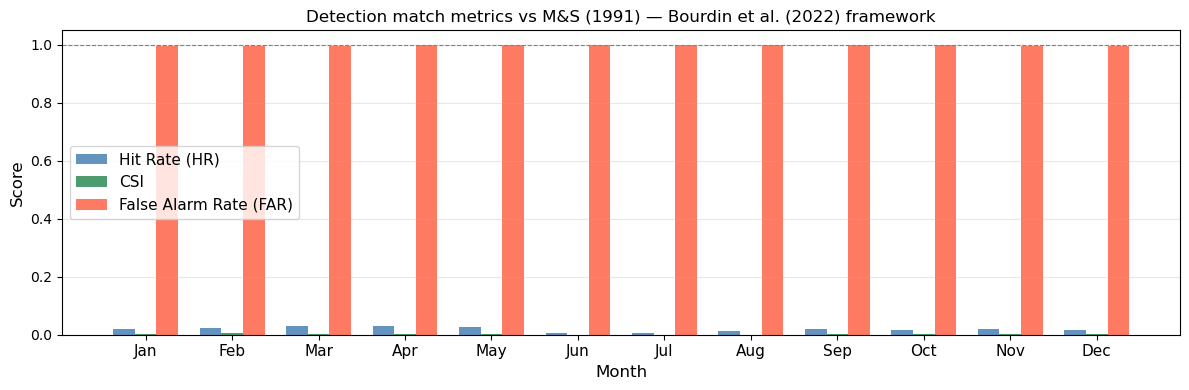

In [8]:
fig = comparison_tracker.plot_match_metrics_monthly(match_stats, figsize=(12, 4))

fig_dir = os.path.join(notebook_directory, 'output', 'figures','comparison')
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, 'comparison_match_metrics_monthly.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Monthly cyclone frequency

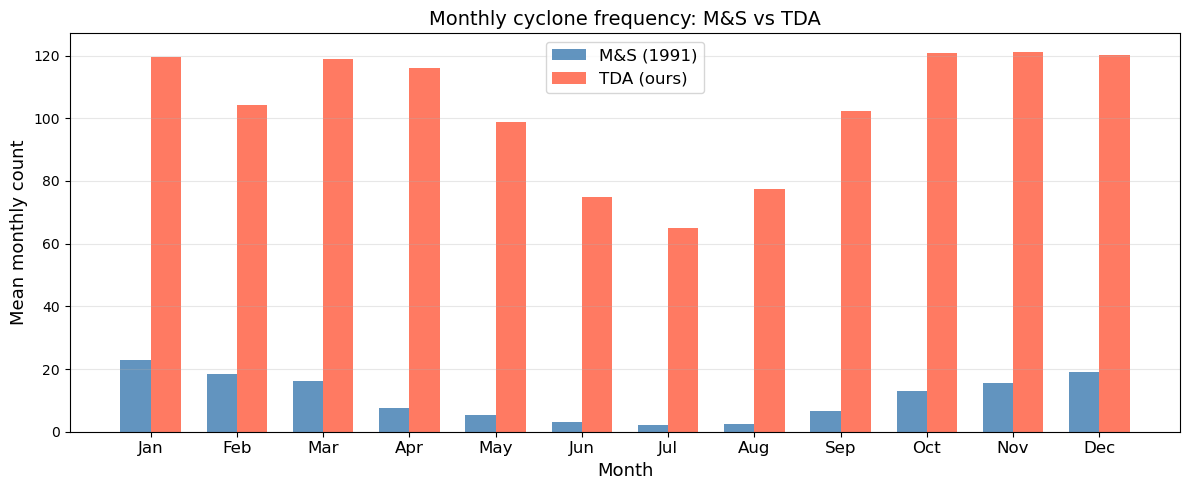

In [9]:
fig = comparison_tracker.plot_monthly_frequency(ms_summary, tda_summary, figsize=(12, 5))
fig.savefig(os.path.join(fig_dir, 'comparison_monthly_frequency.png'), dpi=200, bbox_inches='tight')
plt.show()

## 7. Track lifetime distribution

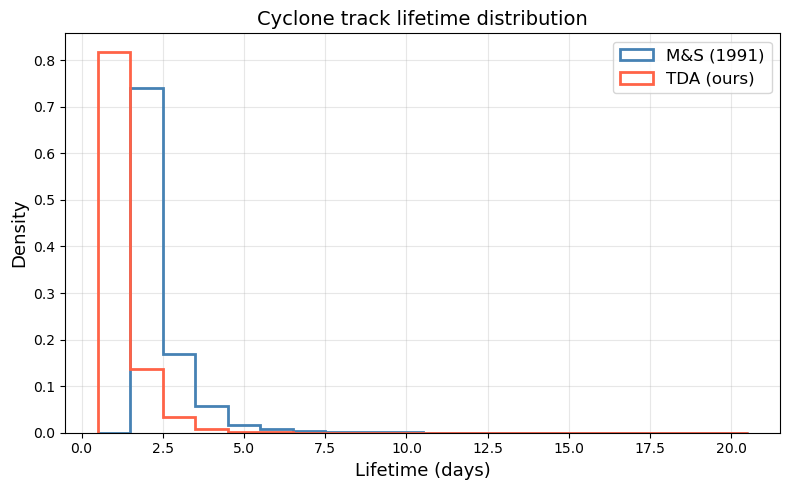

In [10]:
fig = comparison_tracker.plot_lifetime_distribution(ms_summary, tda_summary, max_days=20)
fig.savefig(os.path.join(fig_dir, 'comparison_lifetime_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

## 8. Cyclone genesis spatial density

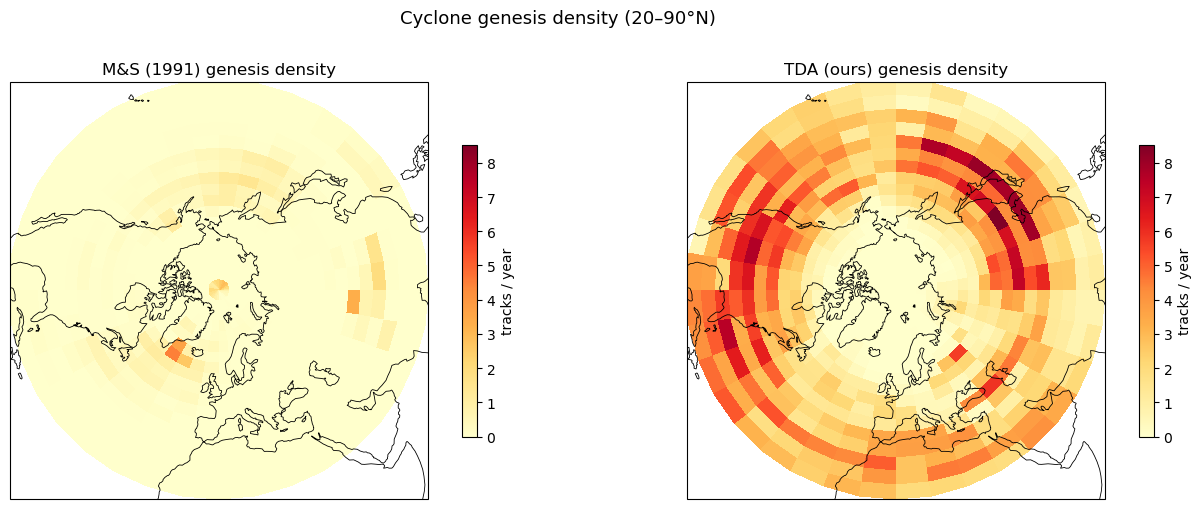

In [11]:
fig = comparison_tracker.plot_spatial_density(ms_summary, tda_summary, figsize=(14, 5))
fig.savefig(os.path.join(fig_dir, 'comparison_spatial_density.png'), dpi=200, bbox_inches='tight')
plt.show()

## 9. Summary comparison table

In [12]:
comparison_tracker.combined_summary_table(ms_summary, tda_summary, match_stats)

ALGORITHM INTERCOMPARISON SUMMARY

M&S (1991)
----------------------------------------
  Total tracks                        9938
  Mean lifetime (days)                2.4
  Median lifetime (days)              2.0
  Mean genesis lat (°N)               66.5
  Mean displacement (km)              345
  Tracks ≥ 3 days (%)                 25.9

TDA (ours)
----------------------------------------
  Total tracks                        94169
  Mean lifetime (days)                1.2
  Median lifetime (days)              1.0
  Mean genesis lat (°N)               35.7
  Mean displacement (km)              132
  Tracks ≥ 3 days (%)                 4.6

Match statistics
----------------------------------------
  Mean Hit Rate (HR)                  0.020
  Mean False Alarm Rate (FAR)         0.994
  Mean CSI                            0.005


## 10. Key findings



| Aspect | M&S (1991) | TDA (ours) |
|--------|------------|------------|
| Detection basis | Local SLP minima + depth threshold | Topological persistence of SLP-anomaly features |
| Significance filter | Depth >= 5 hPa | Persistence >= 10 hPa |
| Shape information | Centre point only | Full representative cycle (extent, area) |
| Noise sensitivity | Sensitive to small-scale SLP noise | Filtered by persistence (topologically stable) |
| Track linking | Nearest-neighbour (distance only) | Wasserstein distance (shape + position) |
| Anticyclones | Separate run needed | Native (sublevel features) |

**Where TDA agrees with M&S**: Seasonal frequency cycle, geographic distribution of storm-track regions (North Atlantic, North Pacific).

**Where TDA differs / improves**:
- TDA detects fewer short-lived (1-day) events because persistence naturally filters topologically insignificant features.
- TDA captures the *spatial extent* (representative 1-cycle) rather than a single centre point.
- Cyclones and anticyclones are tracked in a single unified framework.
- Track linking uses Wasserstein distance (topological + spatial), reducing sensitivity to rapid centre jumps during deepening.

# 5 hPa

## 1. Run M&S tracker — 5 hPa threshold

- Depth >= 500 Pa (5 hPa) relative to 5-degree surrounding ring
- All other parameters identical to 10 hPa run

In [13]:
ms_tracks_5 = comparison_tracker.run_ms_tracker_cached(
    notebook_directory,
    start_year=1948, end_year=2023,
    depth_threshold_pa=500.0,
    max_dist_km=1000.0,
    min_track_days=2,
    lat_min=0.0, lat_max=90.0,
)
print(f'Total M&S tracks (5 hPa): {len(ms_tracks_5)}')

Running M&S tracker on NCEP SLP data …


Detecting centres: 100%|██████████| 27919/27919 [01:48<00:00, 257.27it/s]


Linking tracks (max_dist=1000.0 km, min_days=2) …
M&S tracker: 147050 tracks — saved to ms_tracks_1948-2023_depth500_dist1000_mindays2_lat0-90.pkl
Total M&S tracks (5 hPa): 147050


## 2. Load TDA tracks — 5 hPa threshold

In [14]:
results_sup_5 = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948, end_year=2023,
    data_type='sup',
    notebook_dir=notebook_directory,
    persistence_threshold=500,
    alpha=0, beta=1,
    distance_threshold=1000,
    matrix_size=172,
)

tda_tracks_5 = comparison_tracker.extract_tda_tracks(results_sup_5)
print(f'Total TDA tracks (5 hPa): {len(tda_tracks_5)}')

COMPUTING TRAJECTORY ANALYSIS
Parameters: {'start_year': 1948, 'end_year': 2023, 'data_type': 'sup', 'persistence_threshold': 500, 'alpha': 0, 'beta': 1, 'distance_threshold': 1000, 'matrix_size': 172, 'lat_range': [0, 90], 'lon_range': [0, 360]}
Results will be cached to: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sup_1948-2023_pers500_a0_b1_dist1000_size172.pkl
Analyzing trajectories for years 1948-2023
Data type: sup
Using Wasserstein matching with geodesic distance filter:
C = 0 * d_topological + 1 * d_spatial_km <= 1000
Matrix size: 172x172
Processing 27721 time points...
Processing time step 1/27721 - 1948-01-01
Processing time step 101/27721 - 1948-04-11
Processing time step 201/27721 - 1948-07-20
Processing time step 301/27721 - 1948-10-28
Processing time step 401/27721 - 1949-02-06
Processing time step 501/27721 - 1949-05-17
Processing time step 601/27721 - 1949-08-25
Processing time step 701/277

## 3. Summary & match stats — 5 hPa

In [15]:
ms_summary_5  = comparison_tracker.tracks_to_summary(ms_tracks_5,  label='M&S 5hPa')
tda_summary_5 = comparison_tracker.tracks_to_summary(tda_tracks_5, label='TDA 5hPa')
match_stats_5 = comparison_tracker.compute_daily_match_stats(ms_tracks_5, tda_tracks_5, threshold_km=500.0)

print('M&S (5 hPa):')
print(ms_summary_5[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))
print('\nTDA (5 hPa):')
print(tda_summary_5[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))
print('\nMatch metrics:')
print(match_stats_5[['hit_rate','far','csi']].mean().round(3))

M&S (5 hPa):
       lifetime_days  genesis_lat  total_displacement_km
count       147050.0     147050.0               147050.0
mean             3.3         73.9                  386.5
std              2.2         21.6                  725.6
min              2.0          5.0                    0.0
25%              2.0         55.0                    0.0
50%              3.0         90.0                    0.0
75%              4.0         90.0                  564.9
max            146.0         90.0                12218.3

TDA (5 hPa):
       lifetime_days  genesis_lat  total_displacement_km
count       178515.0     178515.0               178515.0
mean             1.2         37.2                  105.9
std              0.6         14.9                  304.3
min              1.0          1.0                    0.0
25%              1.0         26.2                    0.0
50%              1.0         37.7                    0.0
75%              1.0         48.5                    0.0
max 

# 20 hPa

## 1. Run M&S tracker — 20 hPa threshold

- Depth >= 2000 Pa (20 hPa) relative to 5-degree surrounding ring
- All other parameters identical to 10 hPa run

In [16]:
ms_tracks_20 = comparison_tracker.run_ms_tracker_cached(
    notebook_directory,
    start_year=1948, end_year=2023,
    depth_threshold_pa=2000.0,
    max_dist_km=1000.0,
    min_track_days=2,
    lat_min=0.0, lat_max=90.0,
)
print(f'Total M&S tracks (20 hPa): {len(ms_tracks_20)}')

Running M&S tracker on NCEP SLP data …


Detecting centres: 100%|██████████| 27919/27919 [01:45<00:00, 264.65it/s]

Linking tracks (max_dist=1000.0 km, min_days=2) …
M&S tracker: 6 tracks — saved to ms_tracks_1948-2023_depth2000_dist1000_mindays2_lat0-90.pkl
Total M&S tracks (20 hPa): 6


## 2. Load TDA tracks — 20 hPa threshold

In [17]:
results_sup_20 = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948, end_year=2023,
    data_type='sup',
    notebook_dir=notebook_directory,
    persistence_threshold=2000,
    alpha=0, beta=1,
    distance_threshold=1000,
    matrix_size=172,
)

tda_tracks_20 = comparison_tracker.extract_tda_tracks(results_sup_20)
print(f'Total TDA tracks (20 hPa): {len(tda_tracks_20)}')

COMPUTING TRAJECTORY ANALYSIS
Parameters: {'start_year': 1948, 'end_year': 2023, 'data_type': 'sup', 'persistence_threshold': 2000, 'alpha': 0, 'beta': 1, 'distance_threshold': 1000, 'matrix_size': 172, 'lat_range': [0, 90], 'lon_range': [0, 360]}
Results will be cached to: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sup_1948-2023_pers2000_a0_b1_dist1000_size172.pkl
Analyzing trajectories for years 1948-2023
Data type: sup
Using Wasserstein matching with geodesic distance filter:
C = 0 * d_topological + 1 * d_spatial_km <= 1000
Matrix size: 172x172
Processing 27721 time points...
Processing time step 1/27721 - 1948-01-01
Processing time step 101/27721 - 1948-04-11
Processing time step 201/27721 - 1948-07-20
Processing time step 301/27721 - 1948-10-28
Processing time step 401/27721 - 1949-02-06
Processing time step 501/27721 - 1949-05-17
Processing time step 601/27721 - 1949-08-25
Processing time step 701/2

## 3. Summary & match stats — 20 hPa

In [18]:
ms_summary_20  = comparison_tracker.tracks_to_summary(ms_tracks_20,  label='M&S 20hPa')
tda_summary_20 = comparison_tracker.tracks_to_summary(tda_tracks_20, label='TDA 20hPa')
match_stats_20 = comparison_tracker.compute_daily_match_stats(ms_tracks_20, tda_tracks_20, threshold_km=500.0)

print('M&S (20 hPa):')
print(ms_summary_20[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))
print('\nTDA (20 hPa):')
print(tda_summary_20[['lifetime_days','genesis_lat','total_displacement_km']].describe().round(1))
print('\nMatch metrics:')
print(match_stats_20[['hit_rate','far','csi']].mean().round(3))

M&S (20 hPa):
       lifetime_days  genesis_lat  total_displacement_km
count            6.0          6.0                    6.0
mean             2.7         41.7                  267.7
std              1.2         17.4                  228.4
min              2.0         25.0                    0.0
25%              2.0         32.5                   69.3
50%              2.0         32.5                  319.3
75%              2.8         55.0                  387.8
max              5.0         65.0                  571.1

TDA (20 hPa):
       lifetime_days  genesis_lat  total_displacement_km
count        30084.0      30084.0                30084.0
mean             1.3         34.4                  181.7
std              0.7         11.1                  406.5
min              1.0          6.0                    0.0
25%              1.0         26.4                    0.0
50%              1.0         34.9                    0.0
75%              1.0         42.1                    0.0
ma

# Threshold Comparison Table

Cross-threshold summary: how track statistics and match quality vary with the persistence / depth threshold (5, 10, 20 hPa).

In [19]:
def _row(threshold_label, ms_sum, tda_sum, match):
    ms_ref = match.dropna(subset=['hit_rate', 'far', 'csi'])
    return {
        'Threshold': threshold_label,
        'M&S Tracks':          len(ms_sum),
        'TDA Tracks':          len(tda_sum),
        'M&S Mean Life (d)':   round(ms_sum['lifetime_days'].mean(), 1),
        'TDA Mean Life (d)':   round(tda_sum['lifetime_days'].mean(), 1),
        'M&S Max Life (d)':    int(ms_sum['lifetime_days'].max()),
        'TDA Max Life (d)':    int(tda_sum['lifetime_days'].max()),
        'M&S Genesis Lat (°N)': round(ms_sum['genesis_lat'].mean(), 1),
        'TDA Genesis Lat (°N)': round(tda_sum['genesis_lat'].mean(), 1),
        'M&S Displacement (km)': round(ms_sum['total_displacement_km'].mean()),
        'TDA Displacement (km)': round(tda_sum['total_displacement_km'].mean()),
        'HR':  round(ms_ref['hit_rate'].mean(), 3),
        'FAR': round(ms_ref['far'].mean(), 3),
        'CSI': round(ms_ref['csi'].mean(), 3),
    }

rows = [
    _row(' 5 hPa',  ms_summary_5,   tda_summary_5,  match_stats_5),
    _row('10 hPa',  ms_summary,     tda_summary,    match_stats),
    _row('20 hPa',  ms_summary_20,  tda_summary_20, match_stats_20),
]

comparison_df = pd.DataFrame(rows).set_index('Threshold')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(comparison_df.to_string())
comparison_df

           M&S Tracks  TDA Tracks  M&S Mean Life (d)  TDA Mean Life (d)  M&S Max Life (d)  TDA Max Life (d)  M&S Genesis Lat (°N)  TDA Genesis Lat (°N)  M&S Displacement (km)  TDA Displacement (km)     HR    FAR    CSI
Threshold                                                                                                                                                                                                                 
 5 hPa         147050      178515                3.3                1.2               146                11                  73.9                  37.2                    386                    106  0.024  0.969  0.013
10 hPa           9938       94169                2.4                1.2                34                11                  66.5                  35.7                    345                    132  0.020  0.994  0.005
20 hPa              6       30084                2.7                1.3                 5                11                 

,M&S Tracks,TDA Tracks,M&S Mean Life (d),TDA Mean Life (d),M&S Max Life (d),TDA Max Life (d),M&S Genesis Lat (°N),TDA Genesis Lat (°N),M&S Displacement (km),TDA Displacement (km),HR,FAR,CSI
Threshold,,,,,,,,,,,,,
5 hPa,147050,178515,3.3,1.2,146,11,73.9,37.2,386,106,0.024,0.969,0.013
10 hPa,9938,94169,2.4,1.2,34,11,66.5,35.7,345,132,0.020,0.994,0.005
20 hPa,6,30084,2.7,1.3,5,11,41.7,34.4,268,182,0.000,1.000,0.000
